In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sentence_transformers import SentenceTransformer
from sklearn import svm

In [13]:
sentence_transformer = SentenceTransformer('all-mpnet-base-v2')

In [ ]:
train_df = pd.read_csv('data/generated/dota2/privacy_protected/summary_stats_dota2_gen.csv')
test_df = pd.read_csv('data/initial_datasets/dota2/dota2_test.csv')

In [10]:
test_df

,messages,labels
0,?,0
1,"""is this solo?""",0
2,lol,0
3,"""please report that kunka please""",0
4,"""dauhdasduhas""",0
...,...,...
995,so close,0
996,"""I had ping""",0
997,"""sf well done""",0
998,x,0


In [11]:
train_df = train_df.sample(n=1000)

In [15]:
X_train = np.array(sentence_transformer.encode(train_df['messages'].to_list()))
y_train = train_df['labels']

X_test = np.array(sentence_transformer.encode(test_df['messages'].to_list()))
y_test = test_df['labels']

model = svm.SVC(kernel='linear', probability=True, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test Acc: {test_acc}")

y_prob = model.predict_proba(X_test)[:, 1]
print(f"Roc Auc: {roc_auc_score(y_test, y_prob)}")

print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")

Test Acc: 0.922
Roc Auc: 0.9373991470723835
Precision: 0.2765957446808511
Recall: 0.7222222222222222


In [ ]:
df = pd.read_csv('data/generated/reddit/token_co_occurences/token_co_occurences.csv')
df.sample(n=5)

,messages,labels
60,Glad to help you out today! :),0
1097,Seeing that just ruined my entire day. 😩,1
694,"You're doing a fantastic job, keep it up!",0
125,It’s obvious the outcome was terrible.,1
685,"Wow, the new update basically ruined everythin...",1


In [71]:
train_df = pd.read_csv('data/generated/dota2/privacy_protected/summary_stats_dota2_gen.csv')

In [72]:
train_df['word'] = train_df['messages'].str.split()
train_df['num_words'] = train_df['word'].apply(lambda x: len(x))

In [73]:
data = train_df['num_words']

In [43]:
train_df['num_words'].max()

np.int64(10)

In [74]:
bins = [i for i in range(0, 26, 2)]

In [59]:
bins

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

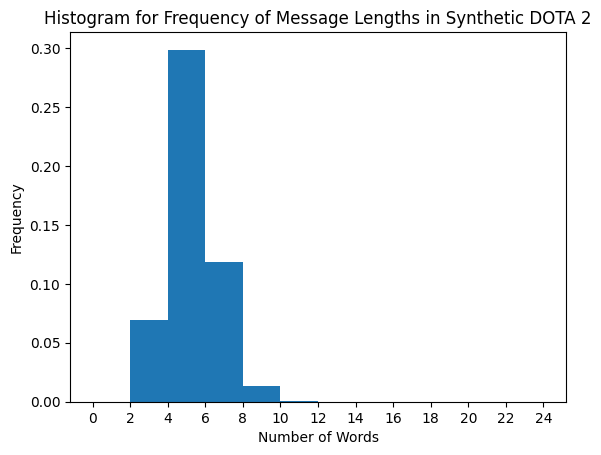

In [75]:
plt.hist(data, bins=bins, density=True, label='Data histogram')
plt.xticks(bins)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram for Frequency of Message Lengths in Synthetic DOTA 2')
plt.savefig('dota2_hist_synth.jpg')

In [76]:
train_df = pd.read_csv('data/initial_datasets/dota2/dota2_train.csv')

In [77]:
train_df['word'] = train_df['messages'].str.split()
train_df['num_words'] = train_df['word'].apply(lambda x: len(x))

In [66]:
train_df['num_words'].max()

np.int64(22)

In [78]:
data = train_df['num_words']

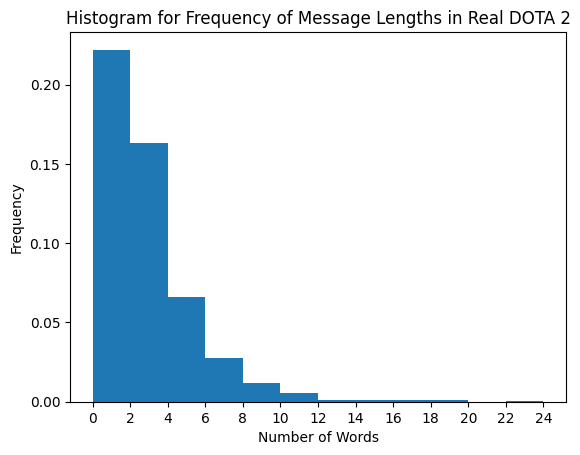

In [79]:
plt.hist(data, bins=bins, density=True, label='Data histogram')
plt.xticks(bins)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram for Frequency of Message Lengths in Real DOTA 2')
plt.savefig('dota2_hist_orig.jpg')

In [69]:
data = train_df['num_words']
loc, scale = expon.fit(data)

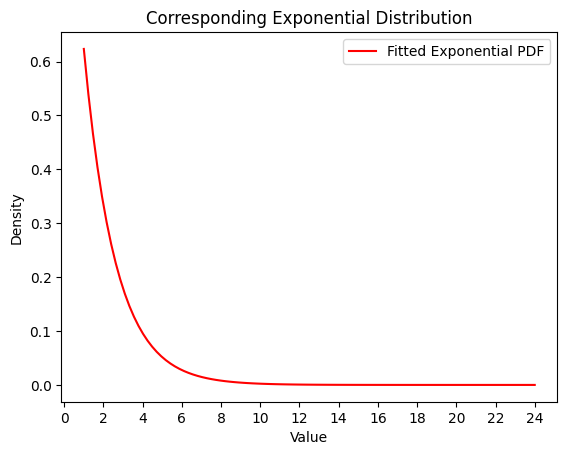

In [70]:
x = np.linspace(1, max(data) + 2, 100)
pdf_fitted = expon.pdf(x, loc=loc, scale=scale)

# plt.hist(data, bins=10, density=True, alpha=0.6, label='Data histogram')
plt.plot(x, pdf_fitted, 'r-', label='Fitted Exponential PDF')
plt.xticks(bins)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.title('Corresponding Exponential Distribution')
plt.savefig('exponential_pdf.jpg')